## Analysis 5 — Text Analysis of BNPL Marketing Copy

**Question:** Do BNPL providers' marketing pages systematically downplay borrowing risks and emphasise urgency?

**Data:**
- `bnpl_website_copy.csv` — 417 text blocks scraped from homepage, how-it-works, and FAQ pages of 6 BNPL providers
- `cfpb_bnpl_complaints.csv` — 74,466 CFPB consumer complaints about the same providers (50k with narrative text)

# Setup

In [64]:
import warnings
warnings.filterwarnings('ignore')
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import textstat
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sns.set_theme(style='whitegrid', palette ='muted', font_scale=1.1)

PROVIDER_ORDER  = ['Affirm', 'Afterpay', 'Klarna', 'PayPal', 'Sezzle', 'Zip']
PROVIDER_COLORS = dict(zip(PROVIDER_ORDER, sns.color_palette('muted', 6)))
PAGE_ORDER      = ['homepage', 'how_it_works', 'faq']
DOWNLOADS       = os.path.expanduser('~/Downloads')

print('Ready.')

Ready.


# Loading data

In [66]:
# Website data
web = pd.read_csv(os.path.join(DOWNLOADS, 'bnpl_website_copy.csv'))
web = web[~web['text'].isin(['FETCH_FAILED', 'JS_RENDERED_NO_STATIC_TEXT'])].copy()
web['text'] = web['text'].fillna('').astype(str)

print(f'Website copy: {len(web)} text blocks')
print(web.groupby(['provider', 'page_type']).size().unstack(fill_value=0))

Website copy: 417 text blocks
page_type  faq  homepage  how_it_works
provider                              
Affirm       0         6             6
Afterpay    11        20            25
Klarna      16        44            54
PayPal      15        48             0
Sezzle       0        23            17
Zip        102        18            12


In [67]:
# CFPB complaints data
comp = pd.read_csv(os.path.join(DOWNLOADS, 'cfpb_bnpl_complaints.csv'))

# Mapping CFPB to clean provider labels (Since they use full names)
COMPANY_MAP = {
    'Affirm Holdings, Inc':      'Affirm',
    'Afterpay US Services, LLC': 'Afterpay',
    'Klarna AB':                 'Klarna',
    'Paypal Holdings, Inc':      'PayPal',
    'Sezzle Inc.':               'Sezzle',
    'Zip Co US Inc.':            'Zip',}
comp['provider'] = comp['company'].map(COMPANY_MAP)
comp_bnpl = comp[comp['provider'].notna()].copy()

FLAG_COLS = [c for c in comp_bnpl.columns if c.startswith('flag_')]
for col in FLAG_COLS:
    comp_bnpl[col] = comp_bnpl[col].astype(str).str.lower().map({'true': True, 'false': False})

# Keeping only rows that have a consumer narrative (which we need for flag analysis)
comp_narr = comp_bnpl[comp_bnpl['consumer_narrative'].notna()].copy()

print(f'CFPB complaints: {len(comp_bnpl):,} total, {len(comp_narr):,} with narrative text')
print(comp_bnpl['provider'].value_counts())

CFPB complaints: 49,140 total, 24,683 with narrative text
provider
PayPal      31078
Affirm      14472
Klarna       2109
Sezzle       1146
Zip           312
Afterpay       23
Name: count, dtype: int64


# Defining keyword dictionaries and compute measures

We built 2 keyword lists based on what a responsible borrower would need to know (essentially "risk words") versus what promotional copy tends to emphasise (such as urgency or aspirational wording. For each text block the code computes:


- Flesch-Kincaid grade level (using the `textstat` library)
- Urgency ratio = urgency keyword hits / (urgency + risk hits). This returns NaN when a block contains no keywords at all, and thus those blocks are excluded from urgency ratio averages
- VADER compound sentiment using the `vaderSentiment` library, which is designed for short marketing-style text

In [69]:
RISK_WORDS = [
    'fee', 'fees', 'interest', 'late payment', 'late fee',
    'credit check', 'debt', 'missed payment', 'penalty', 'charges',
    'apr', 'annual percentage', 'overdue', 'collection',
    'default', 'delinquent',
]

URGENCY_WORDS = [
    'now', 'today', 'instantly', 'instant', 'easy', 'stress-free',
    'stress free', 'treat yourself', '0%', 'zero interest',
    'interest-free', 'interest free', 'free', 'simple', 'quick',
    'fast', 'flexible', 'no fees', 'no interest', 'buy now',
    'shop now', 'get started', 'sign up',
]

def count_keywords(text, words):
    t = text.lower()
    return sum(1 for w in words if w in t)

def urgency_ratio(text):
    u = count_keywords(text, URGENCY_WORDS)
    r = count_keywords(text, RISK_WORDS)
    total = u + r
    return u / total if total > 0 else np.nan

analyzer = SentimentIntensityAnalyzer()

web['fk_grade']      = web['text'].apply(textstat.flesch_kincaid_grade)
web['urgency_ratio'] = web['text'].apply(urgency_ratio)
web['vader']         = web['text'].apply(lambda t: analyzer.polarity_scores(t)['compound'])
web['risk_count']    = web['text'].apply(lambda t: count_keywords(t, RISK_WORDS))
web['urgency_count'] = web['text'].apply(lambda t: count_keywords(t, URGENCY_WORDS))

print('Measures computed. Sample:')
web[['provider', 'page_type', 'text', 'fk_grade', 'urgency_ratio', 'vader']].head(6)

Measures computed. Sample:


,provider,page_type,text,fk_grade,urgency_ratio,vader
0,Klarna,homepage,Use Klarna anywhere you shop,5.240000,NaN,0.0000
1,Klarna,homepage,No fees if you pay on time,-1.060000,0.333333,-0.3818
2,Klarna,homepage,Security and buyer protection,15.470000,NaN,0.3400
3,Klarna,homepage,Pay with Klarna at your favorite brands,3.997143,NaN,0.3818
4,Klarna,homepage,The flexible way to pay at Walmart,3.997143,1.000000,0.1280
5,Klarna,homepage,"Warning! You may receive a scam email, SMS, ph...",10.808333,NaN,-0.7177


## Table 1 — Summary by provider

In [71]:
provider_stats = (
    web.groupby('provider')
    .agg(
        Text_Blocks     = ('text',          'count'),
        FK_Mean         = ('fk_grade',      'mean'),
        FK_Median       = ('fk_grade',      'median'),
        Urgency_Mean    = ('urgency_ratio',  lambda x: x.dropna().mean()),
        VADER_Mean      = ('vader',          'mean'),
        Pct_Has_Risk    = ('risk_count',     lambda x: (x > 0).mean() * 100),
        Pct_Has_Urgency = ('urgency_count',  lambda x: (x > 0).mean() * 100),
    )
    .reindex(PROVIDER_ORDER)
    .round(2)
)

print('Table 1. Marketing copy measures by provider')
print('FK = Flesch-Kincaid grade level | Urgency = urgency/(urgency+risk) keyword ratio')
print('VADER = sentiment score (−1 to +1) | Pct columns = % of text blocks containing any match')


provider_stats

Table 1. Marketing copy measures by provider
FK = Flesch-Kincaid grade level | Urgency = urgency/(urgency+risk) keyword ratio
VADER = sentiment score −1 to +1 | Pct columns = % of text blocks containing any match


,Text_Blocks,FK_Mean,FK_Median,Urgency_Mean,VADER_Mean,Pct_Has_Risk,Pct_Has_Urgency
provider,,,,,,,
Affirm,12,7.23,7.83,0.50,0.08,33.33,33.33
Afterpay,56,6.12,5.40,0.54,0.17,26.79,26.79
Klarna,114,9.69,7.81,0.62,0.30,15.79,25.44
PayPal,63,5.33,5.62,0.45,0.15,17.46,14.29
Sezzle,40,6.36,5.53,0.92,0.18,12.50,50.00
Zip,132,5.19,4.62,0.60,0.10,1.52,2.27


## Figure 1 — Three measures across providers

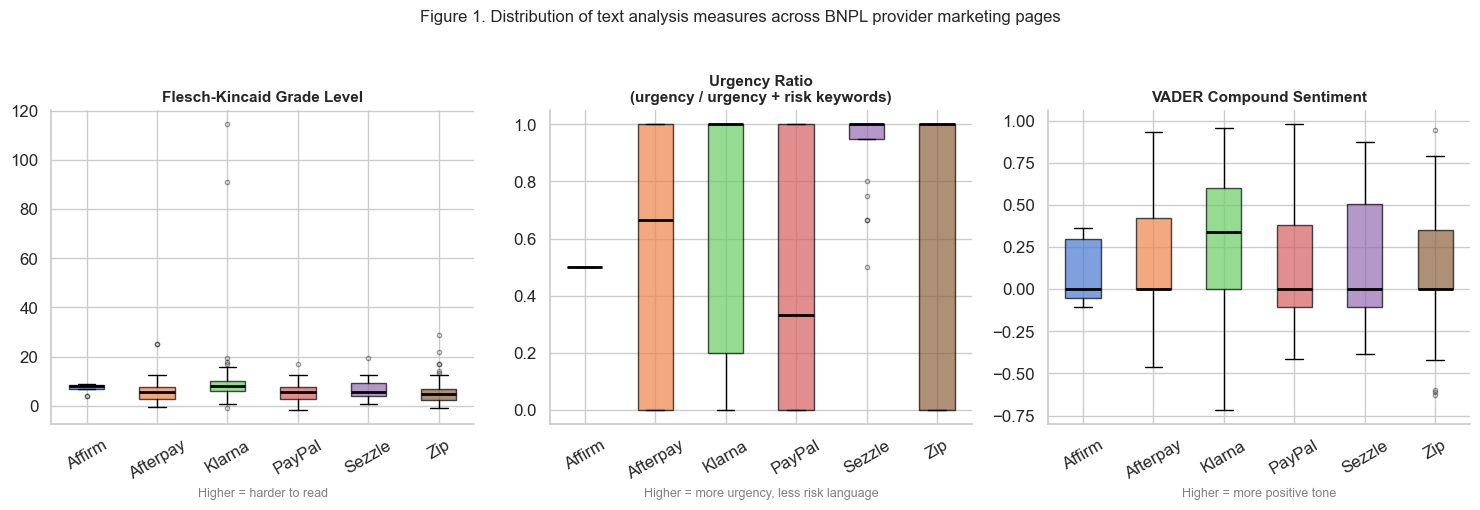

In [73]:
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

measures = [
    ('fk_grade', 'Flesch-Kincaid Grade Level',
     'Higher = harder to read'),
    ('urgency_ratio', 'Urgency Ratio\n(urgency / urgency + risk keywords)',
     'Higher = more urgency, less risk language'),
    ('vader','VADER Compound Sentiment',
     'Higher = more positive tone')]

for ax, (col, title, subtitle) in zip(axes, measures):
    data_by_prov = [
        web.loc[web['provider'] == p, col].dropna().values
        for p in PROVIDER_ORDER]
    bplot = ax.boxplot(
        data_by_prov,
        labels = PROVIDER_ORDER,
        patch_artist = True,
        medianprops = dict(color='black', linewidth = 2),
        flierprops = dict(marker='o', markersize = 3, alpha = 0.4))
    for patch, prov in zip(bplot['boxes'], PROVIDER_ORDER):
        patch.set_facecolor(PROVIDER_COLORS[prov])
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(subtitle, fontsize=9, color='grey')
    ax.tick_params(axis='x', rotation=30)
    sns.despine(ax=ax)

fig.suptitle('Figure 1. Distribution of text analysis measures across BNPL provider marketing pages',fontsize = 12, y = 1.02)
plt.tight_layout()
plt.savefig(os.path.join(DOWNLOADS, 'fig1_provider_measures.png'), dpi = 150, bbox_inches='tight')

plt.show()

## 5. Asking our question: Does language differ by page type?

If providers are strategically downplaying risk, one would expect homepage copy (the primary consumer touchpoint) to be more positive and urgent than FAQ copy (where disclosures live)

In [75]:
page_stats = (
    web.groupby('page_type')
    .agg(
        n            = ('text',          'count'),
        FK_Mean      = ('fk_grade',      'mean'),
        FK_SD        = ('fk_grade',      'std'),
        Urgency_Mean = ('urgency_ratio',  lambda x: x.dropna().mean()),
        Urgency_SD   = ('urgency_ratio',  lambda x: x.dropna().std()),
        VADER_Mean   = ('vader',          'mean'),
        VADER_SD     = ('vader',          'std'),
        Pct_Has_Risk = ('risk_count',     lambda x: (x > 0).mean() * 100),
    )
    .reindex(PAGE_ORDER)
    .round(3))

print('Table 2. Measures by page type (mean and SD)')
page_stats

Table 2. Measures by page type (mean and SD)


,n,FK_Mean,FK_SD,Urgency_Mean,Urgency_SD,VADER_Mean,VADER_SD,Pct_Has_Risk
page_type,,,,,,,,
homepage,159,6.111,3.964,0.630,0.421,0.191,0.358,16.981
how_it_works,114,8.272,10.823,0.615,0.420,0.238,0.345,21.930
faq,144,6.211,8.217,0.667,0.500,0.116,0.298,2.083


In [124]:
# Using Welch t tests (homepage vs FAQ for each measure)
hp  = web[web['page_type'] == 'homepage']
faq = web[web['page_type'] == 'faq']

print('Welch t-tests: homepage vs FAQ')
print(f'{"Measure":<30} {"HP mean":>9} {"FAQ mean":>9} {"t":>7} {"p":>8} {"sig":>5}')
print('-' * 75)

for col, label in [
    ('fk_grade',      'FK Grade Level'),
    ('urgency_ratio', 'Urgency Ratio'),
    ('vader',         'VADER Sentiment'),
]:
    a = hp[col].dropna()
    b = faq[col].dropna()
    t, p = stats.ttest_ind(a, b, equal_var = False)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f'{label:<30} {a.mean():>9.3f} {b.mean():>9.3f} {t:>7.3f} {p:>8.4f} {sig:>5}')

print()
print('Key: * p<0.05  ** p<0.01  *** p<0.001 (Welch two tailed, thus not corrected for multiple comparisons)')
print('We run 3 tests (so a single significant result should be interpreted with caution)')

Welch t-tests: homepage vs FAQ
Measure                          HP mean  FAQ mean       t        p   sig
---------------------------------------------------------------------------
FK Grade Level                     6.111     6.211  -0.133   0.8945    ns
Urgency Ratio                      0.630     0.667  -0.209   0.8390    ns
VADER Sentiment                    0.191     0.116   1.975   0.0492     *

Key: * p<0.05  ** p<0.01  *** p<0.001 (Welch two tailed, thus not corrected for multiple comparisons)
We run 3 tests (so a single significant result should be interpreted with caution)


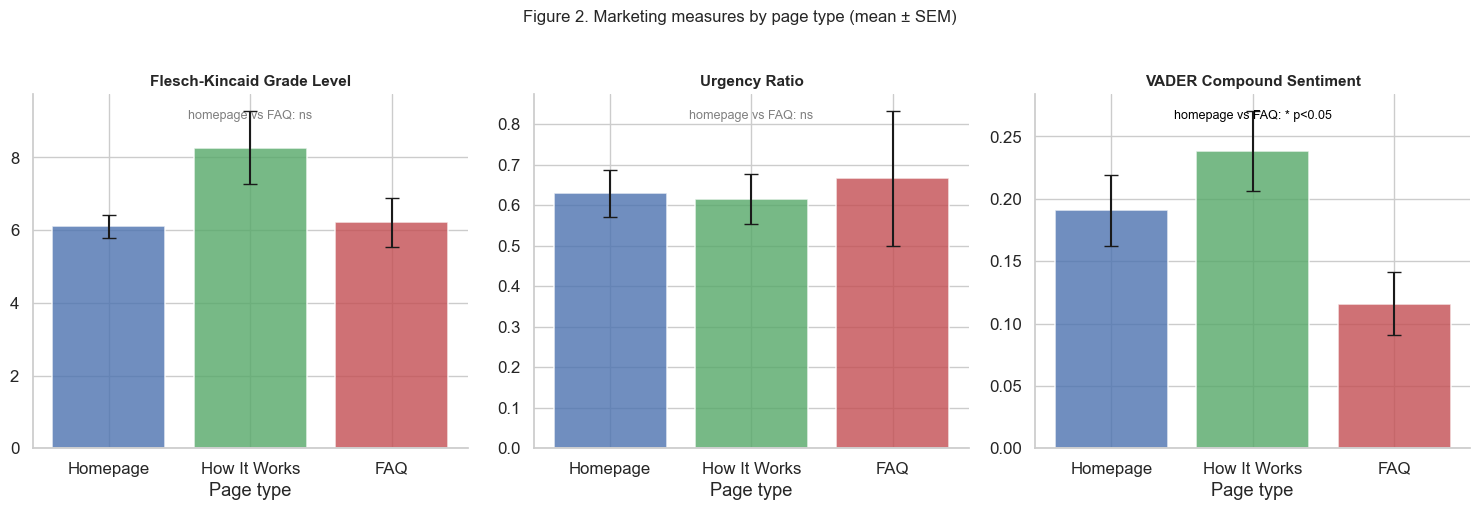

In [77]:
fig, axes = plt.subplots(1, 3, figsize = (15, 5))
page_labels = ['Homepage', 'How It Works', 'FAQ']
page_colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, (col, title) in zip(axes, [
    ('fk_grade',      'Flesch-Kincaid Grade Level'),
    ('urgency_ratio', 'Urgency Ratio'),
    ('vader',         'VADER Compound Sentiment'),
]):
    means = [web[web['page_type'] == p][col].dropna().mean() for p in PAGE_ORDER]
    sems  = [web[web['page_type'] == p][col].dropna().sem()  for p in PAGE_ORDER]
    ax.bar(page_labels, means, yerr = sems, capsize=5,
           color=page_colors, alpha = 0.8, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize = 11, fontweight='bold')
    ax.set_xlabel('Page type')

    # homepage vs FAQ significance
    a = web[web['page_type'] == 'homepage'][col].dropna()
    b = web[web['page_type'] == 'faq'][col].dropna()
    _, p = stats.ttest_ind(a, b, equal_var = False)
    sig = '* p<0.05' if p < 0.05 else 'ns'
    ax.annotate(f'homepage vs FAQ: {sig}',
                xy = (0.5, 0.93), xycoords='axes fraction',
                ha = 'center', fontsize=9,
                color = 'black' if p < 0.05 else 'grey')
    sns.despine(ax = ax)

fig.suptitle('Figure 2. Marketing measures by page type (mean ± SEM)',fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DOWNLOADS, 'fig2_page_type_comparison.png'), dpi=150, bbox_inches='tight')

plt.show()

## Figure 3 — Urgency ratio heatmap by provider and page type

We did this to show whether providers that express heavy urgency on their homepages become more risk-disclosing on their FAQ pages, or if the pattern is consistent across all pages.

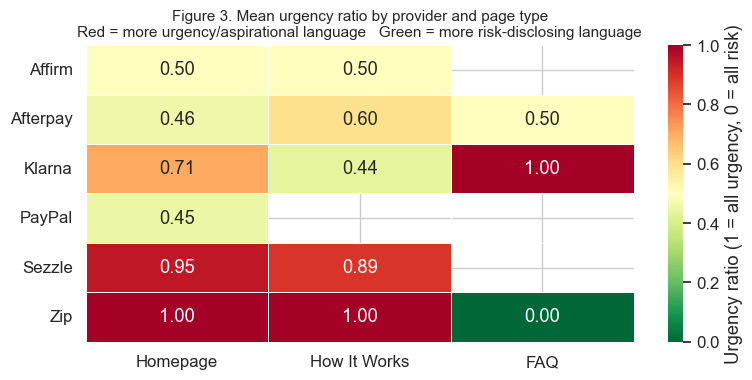

In [126]:
heatmap_data = (
    web.groupby(['provider', 'page_type'])['urgency_ratio']
    .mean()
    .unstack('page_type')
    .reindex(index=PROVIDER_ORDER, columns=PAGE_ORDER))

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.2f',
    cmap='RdYlGn_r',
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
    xticklabels=['Homepage', 'How It Works', 'FAQ'],
    cbar_kws={'label': 'Urgency ratio (1 = all urgency, 0 = all risk)'})
ax.set_title(
    'Figure 3. Mean (average) urgency ratio by provider and page type\n'
    'Red = more urgency/aspirational language   Green = more risk-disclosing language',
    fontsize=11)

ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(DOWNLOADS, 'fig3_urgency_heatmap.png'), dpi = 150, bbox_inches='tight')

plt.show()

## CFPB complaint flag rates by provider

Each flag marks whether a consumer's written complaint contains language suggesting they were misled in a specific way. The rate here is  the percentage of complaint narratives containing each flag (per provider).

In [81]:
flag_rates = (
    comp_narr.groupby('provider')[FLAG_COLS]
    .mean()
    .mul(100)
    .reindex(PROVIDER_ORDER)
    .round(2))
flag_rates.columns = [c.replace('flag_', '').replace('_', ' ').title() for c in FLAG_COLS]
flag_rates['Avg Flag Rate'] = flag_rates.mean(axis=1).round(2)

print('Table 3: CFPB deception flag rates by provider (% of complaint narratives)')
flag_rates

Table 3. CFPB deception flag rates by provider (% of complaint narratives)


,Believed Free,Hidden Fees,Unexpected Late Fee,Debt Accumulation,Credit Impact,Misleading Ad,Loan Confusion,Avg Flag Rate
provider,,,,,,,,
Affirm,0.47,2.03,3.12,20.72,42.12,18.18,0.40,12.43
Afterpay,6.25,6.25,0.00,18.75,0.00,6.25,6.25,6.25
Klarna,0.86,2.37,8.17,15.91,15.70,22.47,0.75,9.46
PayPal,0.33,2.97,1.36,3.89,1.51,17.85,0.58,4.07
Sezzle,0.24,1.95,9.25,20.92,39.17,15.82,0.24,12.51
Zip,0.00,0.00,9.89,6.04,6.59,25.27,1.10,6.98


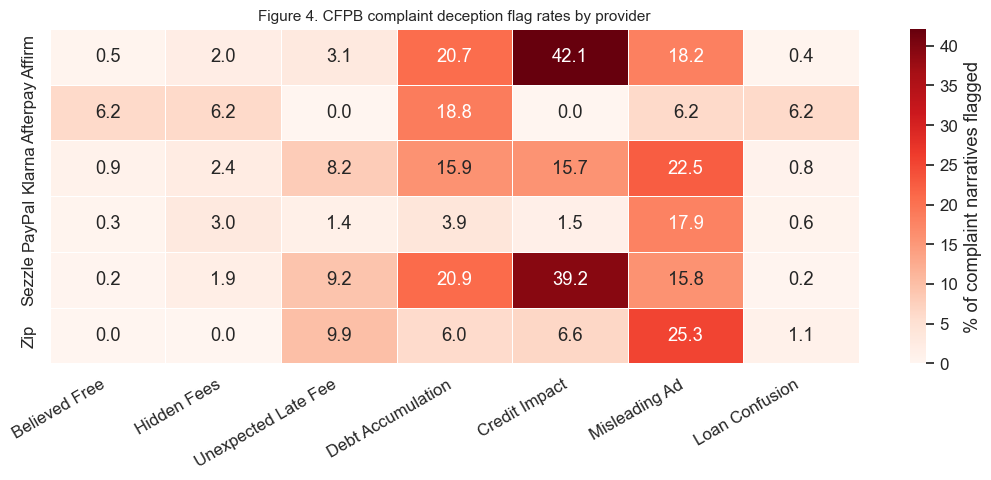

In [82]:
fig, ax = plt.subplots(figsize = (11, 5))
sns.heatmap(
    flag_rates.drop(columns = 'Avg Flag Rate').reindex(PROVIDER_ORDER),
    annot = True, fmt = '.1f',
    cmap = 'Reds',
    linewidths = 0.5,
    ax = ax,
    cbar_kws={'label': '% of complaint narratives flagged'})

ax.set_title('Figure 4. CFPB complaint deception flag rates by provider', fontsize=11)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation = 30, ha = 'right')
plt.tight_layout()
plt.savefig(os.path.join(DOWNLOADS, 'fig4_cfpb_flags.png'), dpi = 150, bbox_inches = 'tight')

plt.show()

## Cross-provider comparison: marketing language vs. complaint rates

With only 6 providers, we can't run a meaningful statistical test, as any p-value from a Pearson correlation with n = 6 would be extremely underpowered/statistically insignificant and not worth reporting. Instead, we show a scatter plot and describe the direction of the pattern. If providers with more urgency-heavy marketing also have higher complaint rates, that is consistent with our argument, but we are careful not to overstate it.

In [84]:
prov_urgency  = web.groupby('provider')['urgency_ratio'].mean().rename('Mean Urgency Ratio')
prov_vader    = web.groupby('provider')['vader'].mean().rename('Mean VADER Sentiment')
prov_risk_pct = web.groupby('provider')['risk_count'].apply(
    lambda x: (x > 0).mean() * 100
).rename('% Blocks With Risk Language')
prov_flags = flag_rates['Avg Flag Rate']

cross = pd.concat([prov_urgency, prov_vader, prov_risk_pct, prov_flags], axis = 1).dropna()

print('Table 4. Cross-provider summary')
cross.round(3)

Table 4. Cross-provider summary


,Mean Urgency Ratio,Mean VADER Sentiment,% Blocks With Risk Language,Avg Flag Rate
provider,,,,
Affirm,0.500,0.084,33.333,12.43
Afterpay,0.542,0.172,26.786,6.25
Klarna,0.622,0.298,15.789,9.46
PayPal,0.451,0.153,17.460,4.07
Sezzle,0.919,0.180,12.500,12.51
Zip,0.600,0.096,1.515,6.98


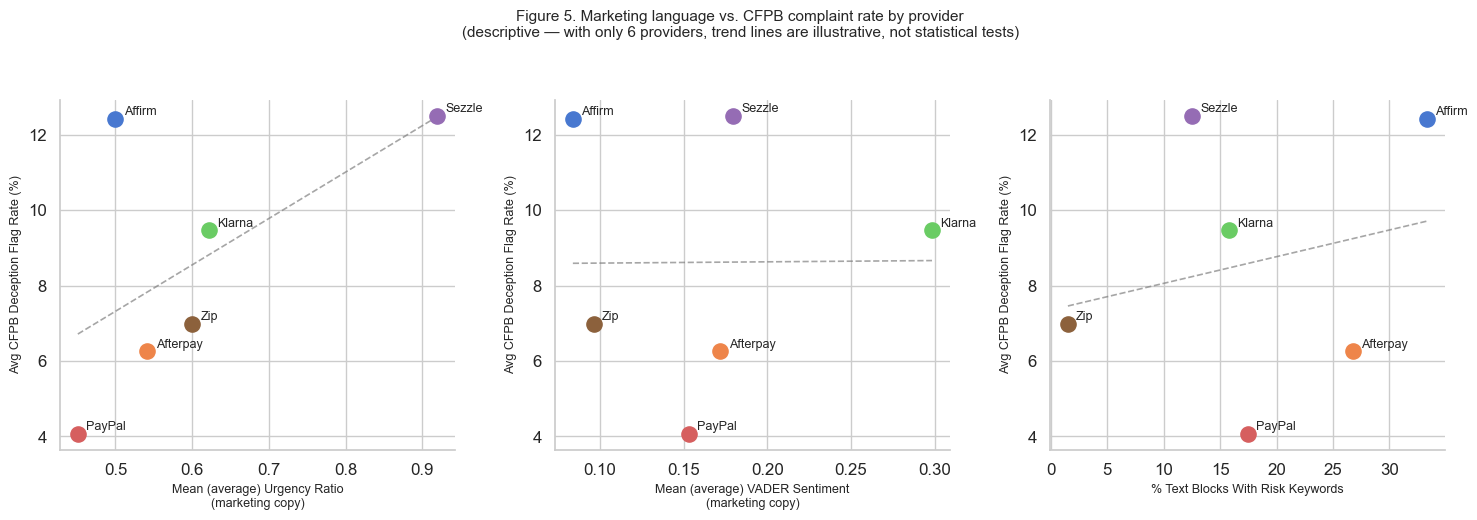

In [134]:
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

for ax, (xcol, xlabel) in zip(axes, [
    ('Mean Urgency Ratio',         'Mean (average) Urgency Ratio\n(marketing copy)'),
    ('Mean VADER Sentiment',       'Mean (average) VADER Sentiment\n(marketing copy)'),
    ('% Blocks With Risk Language','% Text Blocks With Risk Keywords'),
]):
    for prov in cross.index:
        ax.scatter(
            cross.loc[prov, xcol],
            cross.loc[prov, 'Avg Flag Rate'],
            color = PROVIDER_COLORS[prov],
            s = 120, zorder = 3)
        ax.annotate(
            prov,
            (cross.loc[prov, xcol], cross.loc[prov, 'Avg Flag Rate']),
            textcoords = 'offset points', xytext=(6, 3), fontsize=9)

    # Trend line
    x, y = cross[xcol].values, cross['Avg Flag Rate'].values
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m * xline + b, color='grey', linestyle = '--', linewidth = 1.2, alpha = 0.7)
    ax.set_xlabel(xlabel, fontsize = 9)
    ax.set_ylabel('Avg CFPB Deception Flag Rate (%)', fontsize=9)
    sns.despine(ax = ax)

fig.suptitle(
    'Figure 5. Marketing language vs. CFPB complaint rate by provider\n'
    '(descriptive — with only 6 providers, trend lines are illustrative, not statistical tests)',
    fontsize = 11, y = 1.04)

plt.tight_layout()
plt.savefig(os.path.join(DOWNLOADS, 'fig5_crossprovider_scatter.png'), dpi=150, bbox_inches='tight')

plt.show()

## Example quotes from the data

Mere numbers don't convey how the marketing sounds. We pull homepage blocks that are the most urgency-heavy and the most heavily flagged CFPB complaint narratives in order to show the rhetorical pattern.

In [142]:
print('Most urgency-heavy homepage text blocks:')

hp_blocks = web[web['page_type'] == 'homepage']
top_urgency = hp_blocks[hp_blocks['urgency_count'] > 0].nlargest(8, 'urgency_count')

for _, row in top_urgency.iterrows():
    print(f'[{row["provider"]}]  urgency hits={row["urgency_count"]}  '
          f'risk hits={row["risk_count"]}  sentiment={row["vader"]:.2f}')
    print(f'  "{row["text"][:140]}"')
    print()

Most urgency-heavy homepage text blocks:
[Sezzle]  urgency hits=4  risk hits=1  sentiment=0.08
  "Shop in-app or in-store, and buy now pay later in 4 easy installments over 6 weeks & no interest.Â¹"

[Klarna]  urgency hits=2  risk hits=1  sentiment=0.25
  "Shop securely and choose to pay in 4 interest-free payments, in full, in 30 days, or over time.¹"

[Klarna]  urgency hits=2  risk hits=0  sentiment=0.76
  "Enjoy secure shopping, lightning-fast checkout, and flexible payment options that suit your budget."

[Klarna]  urgency hits=2  risk hits=0  sentiment=0.72
  "Enjoy a quick, seamless checkout process that makes shopping faster and easier."

[Affirm]  urgency hits=2  risk hits=2  sentiment=-0.10
  "Options depend on your purchase amount and may vary by merchant. A down payment may be required. For example, at a purchase price of $400 yo"

[Afterpay]  urgency hits=2  risk hits=1  sentiment=-0.10
  "Choose to pay over 3, 6, 12 or 24* months or in 4 interest-free payments at partner b

In [144]:
print('Most flagged CFPB complaint narratives (just the first 300 characters):')
flag_sum = comp_narr[FLAG_COLS].sum(axis = 1)
top_complaints = comp_narr.loc[
    flag_sum.nlargest(6).index,
    ['provider', 'consumer_narrative'] + FLAG_COLS]

for _, row in top_complaints.iterrows():
    active_flags = [f.replace('flag_', '') for f in FLAG_COLS if row[f]]
    print(f'[{row["provider"]}]  Flags triggered: {active_flags}')
    print(f'  "{str(row["consumer_narrative"])[:300]}"')
    print()

Most flagged CFPB complaint narratives (just the first 300 characters):
[Affirm]  Flags triggered: ['unexpected_late_fee', 'debt_accumulation', 'credit_impact', 'misleading_ad', 'loan_confusion']
  "To Whom It May Concern : I submit this complaint against Affirm , Inc. regarding one or more buy-now-pay-later/installment accounts that were paid off as part of my mortgage approval process, yet Affirm has failed to credit the payments and continues to demand payment of balances that should be XXXX"

[Affirm]  Flags triggered: ['hidden_fees', 'unexpected_late_fee', 'debt_accumulation', 'credit_impact', 'misleading_ad']
  "XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX Disputing Inaccuracies on My Credit Report XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX AFFIRM INC XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX X"

[PayPal]  Flags triggered: ['hidden_fees', 'unexpected_late_fee', 'cred